In [2]:
from typing import TypedDict

class State(TypedDict):
    customer_name: str
    my_age: int

In [15]:
def node_1(state: State):
    return state

def node_2(state: State):
    return state

def node_3(state: State):
    return state

def node_4(state: State):
    return state

def node_5(state: State):
    return state

def node_6(state: State):
    return state

def node_7(state: State):
    return state

In [7]:
import random
from typing import Literal

def route_edge(state: State) -> Literal["node_2", "node_3"]:
    if random.random() < 0.5:
        return 'node_2'
    return 'node_3'

In [9]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", route_edge)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

agent = builder.compile()

In [10]:
print(agent.get_graph().draw_ascii())

        +-----------+          
        | __start__ |          
        +-----------+          
               *               
               *               
               *               
          +--------+           
          | node_1 |           
          +--------+           
          .         .          
        ..           ..        
       .               .       
+--------+          +--------+ 
| node_2 |          | node_3 | 
+--------+          +--------+ 
          *         *          
           **     **           
             *   *             
          +---------+          
          | __end__ |          
          +---------+          


In [11]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

builder.add_conditional_edges(START, route_edge)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

agent = builder.compile()
print(agent.get_graph().draw_ascii())

        +-----------+          
        | __start__ |          
        +-----------+          
          .         .          
        ..           ..        
       .               .       
+--------+          +--------+ 
| node_2 |          | node_3 | 
+--------+          +--------+ 
          *         *          
           **     **           
             *   *             
          +---------+          
          | __end__ |          
          +---------+          


In [14]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)
builder.add_node("node_5", node_5)

builder.add_conditional_edges(START, route_edge)
builder.add_edge("node_2", "node_4")
builder.add_edge("node_4", END)
builder.add_edge("node_3", "node_5")
builder.add_edge("node_5", END)

agent = builder.compile()
print(agent.get_graph().draw_ascii())

        +-----------+          
        | __start__ |          
        +-----------+          
          .         .          
        ..           ..        
       .               .       
+--------+          +--------+ 
| node_2 |          | node_3 | 
+--------+          +--------+ 
     *                   *     
     *                   *     
     *                   *     
+--------+          +--------+ 
| node_4 |          | node_5 | 
+--------+          +--------+ 
          *         *          
           **     **           
             *   *             
          +---------+          
          | __end__ |          
          +---------+          


In [16]:
import random
from typing import Literal

def route_edge_2(state: State) -> Literal["node_6", "node_7"]:
    if random.random() < 0.5:
        return 'node_6'
    return 'node_7'

In [18]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)
builder.add_node("node_4", node_4)
builder.add_node("node_5", node_5)
builder.add_node("node_6", node_5)
builder.add_node("node_7", node_5)

builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", route_edge)
builder.add_edge("node_2", "node_4")
builder.add_edge("node_4", END)
builder.add_edge("node_3", "node_5")
builder.add_conditional_edges("node_5", route_edge_2)
builder.add_edge("node_6", END)
builder.add_edge("node_6", "node_1")

agent = builder.compile()

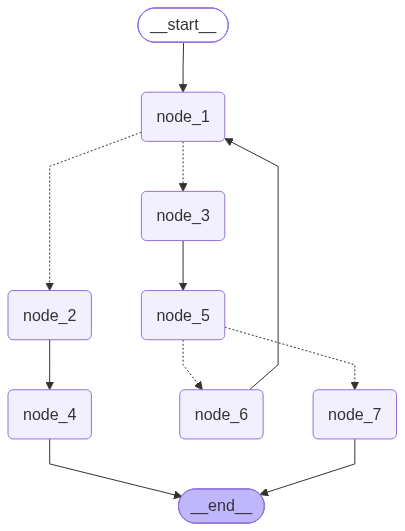

In [19]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))